In [2]:
import keras
import tensorflow as tf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. 클래스 이름 정의 (CIFAR-10 공식 순서)
classes = ['비행기', '자동차', '새', '고양이', '사슴', '개', '개구리', '말', '배', '트럭']

# 3. 데이터 차원 확인
print("==== 데이터 구조 확인 ====")
print(f"Train 이미지 차원: {x_train.shape}")  # (50000, 32, 32, 3) -> 5만장, 32x32 해상도, RGB 3채널
print(f"Train 라벨 차원: {y_train.shape}")    # (50000, 1)
print(f"Test 이미지 차원: {x_test.shape}")    # (10000, 32, 32, 3)
print(f"테스트 데이터 비율: {len(x_test) / (len(x_train) + len(x_test)) * 100:.1f}%")
print(f"픽셀 최솟값: {x_train.min()}, 최댓값: {x_train.max()}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
==== 데이터 구조 확인 ====
Train 이미지 차원: (50000, 32, 32, 3)
Train 라벨 차원: (50000, 1)
Test 이미지 차원: (10000, 32, 32, 3)
테스트 데이터 비율: 16.7%
픽셀 최솟값: 0, 최댓값: 255


c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: Use

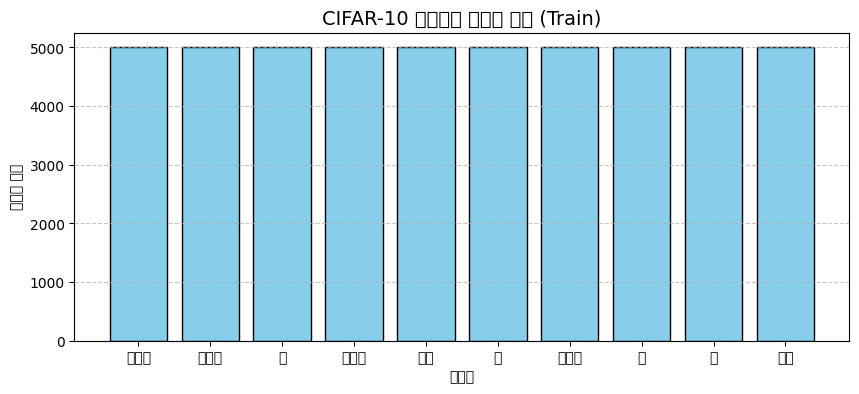

클래스별 개수: {'비행기': np.int64(5000), '자동차': np.int64(5000), '새': np.int64(5000), '고양이': np.int64(5000), '사슴': np.int64(5000), '개': np.int64(5000), '개구리': np.int64(5000), '말': np.int64(5000), '배': np.int64(5000), '트럭': np.int64(5000)}


In [5]:
# 클래스별 빈도수 계산
unique, counts = np.unique(y_train, return_counts=True)

# 시각화
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경 (맥은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.title('CIFAR-10 클래스별 데이터 분포 (Train)', fontsize=14)
plt.xlabel('클래스')
plt.ylabel('데이터 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("클래스별 개수:", dict(zip(classes, counts)))

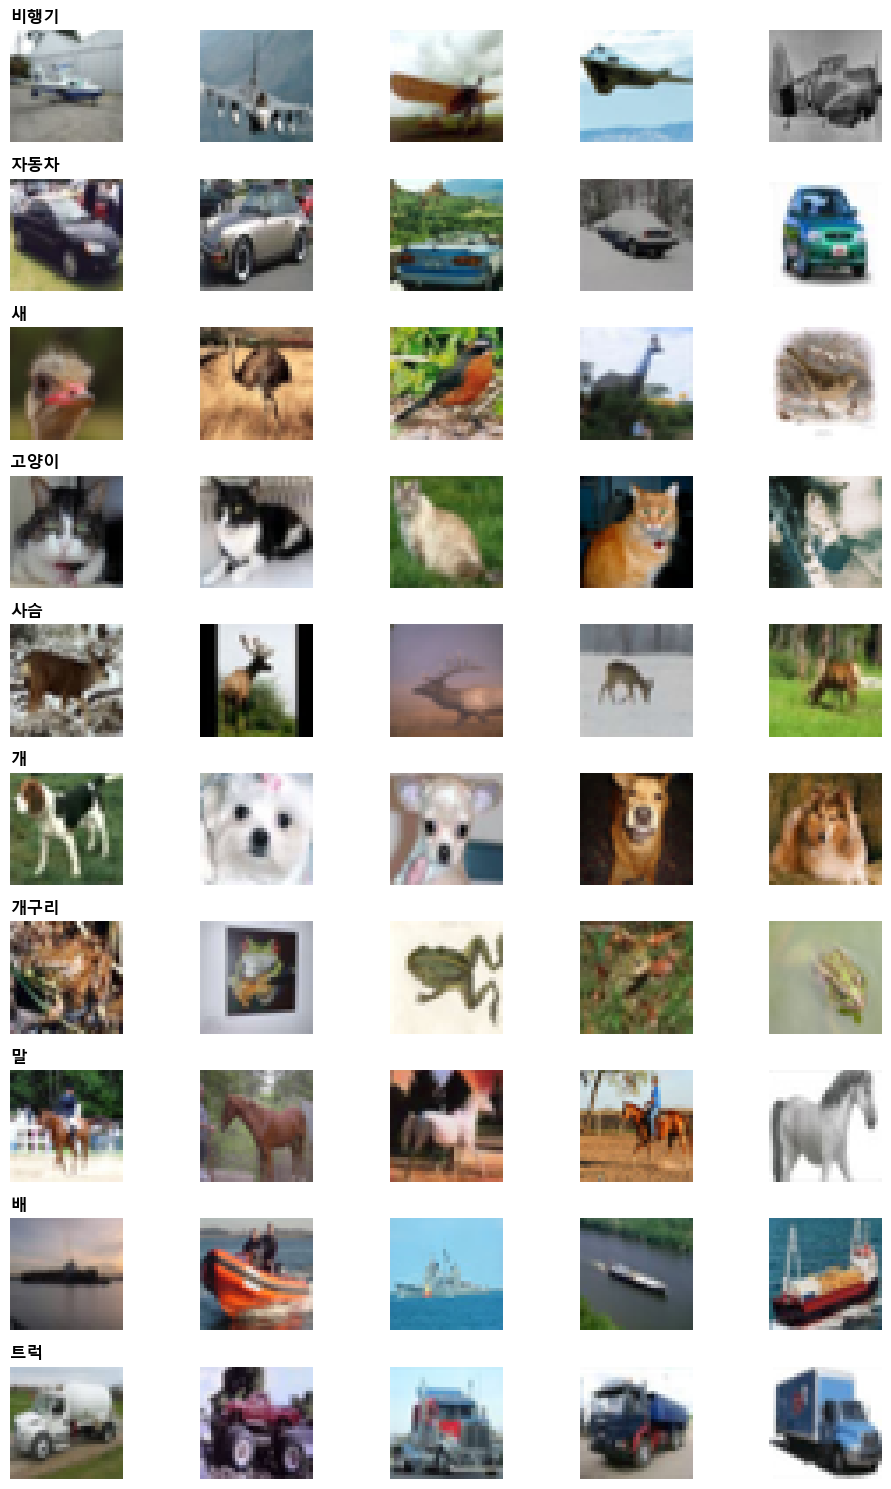

In [6]:
num_classes = 10
samples_per_class = 5

# 10행 5열의 서브플롯 생성
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 15))

for cluster_idx, class_name in enumerate(classes):
    # 해당 클래스의 인덱스만 추출
    idx = np.flatnonzero(y_train == cluster_idx)
    # 무작위로 5개 선택
    rand_idx = np.random.choice(idx, samples_per_class, replace=False)
    
    for i, img_idx in enumerate(rand_idx):
        ax = axes[cluster_idx, i]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        
        # 첫 번째 열에만 클래스 이름 표시
        if i == 0:
            ax.set_title(class_name, loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()